# Tecnica de estandarizacion y PCA
## 1. Carga de la Base de Datos Enriquecida

En este tercer notebook, comenzamos importando nuestra matriz de características ya procesada, la cual contiene las 16 métricas de scouting P90 ajustadas y la información categórica de cada jugador (Liga, Equipo y Posición).

In [2]:
import pandas as pd
from IPython.display import display

# 1. Cargar la base de datos enriquecida
ruta_archivo = '/content/drive/MyDrive/dataset_perfiles_jugadores_1516.csv'
df = pd.read_csv(ruta_archivo)

# Verificamos que la base esté lista y tenga las nuevas columnas
print("="*60)
print(f"✅ Base cargada: {df.shape[0]} jugadores y {df.shape[1]} columnas.")
print("="*60)
display(df[['player', 'team', 'competition_name', 'position_group']].head())

✅ Base cargada: 1699 jugadores y 22 columnas.


,player,team,competition_name,position_group
0,Aaron Cresswell,West Ham United,Premier League,Defensa
1,Aaron Lennon,Everton,Premier League,Mediocampista
2,Aaron Ramsey,Arsenal,Premier League,Mediocampista
3,Abdelaziz Barrada,Marseille,Ligue 1,Mediocampista
4,Abdelaziz Barrada,Olympique de Marseille,Ligue 1,Mediocampista


## 2. Limpieza de Datos y Filtro de Multicolinealidad

Antes de estandarizar y aplicar el Análisis de Componentes Principales (PCA), debemos asegurar que nuestro modelo no sufra de "secuestro de varianza" ni de errores matemáticos. Si introducimos variables que miden prácticamente lo mismo (correlación > 0.85 o 0.90), el PCA le dará un peso desproporcionado a ese rasgo táctico.

Utilizando los hallazgos de nuestra estadística descriptiva y la matriz de correlación como **filtro cuantitativo**, hemos depurado el ecosistema eliminando dos métricas problemáticas:

1. **Duelos Aéreos Ganados P90 (Varianza Cero):** Como detectamos en la fase de EDA, esta variable arrojó valores de 0 absoluto para toda la población estadística (debido a la falta de registro o nomenclatura distinta en la temporada 15/16). Mantenerla colapsaría la estandarización posterior (generando un error de división por cero al aplicar el Z-Score) y no aporta varianza al modelo.
2. **Influencia Global P90 (Alta Correlación):** La matriz detectó una correlación crítica de **0.89** entre esta métrica y las variables *Pases Último Tercio P90* y *Conducciones Progresivas P90*. Dado que la "Influencia" es una métrica de volumen general, decidimos eliminarla para retener las otras dos, ya que estas explican de manera mucho más rica y específica *cómo* el jugador hace progresar el balón hacia el ataque, evitando así sobreponderar la simple participación.

✅ Base cargada: 1699 jugadores y 22 columnas.


,player,team,competition_name,position_group
0,Aaron Cresswell,West Ham United,Premier League,Defensa
1,Aaron Lennon,Everton,Premier League,Mediocampista
2,Aaron Ramsey,Arsenal,Premier League,Mediocampista
3,Abdelaziz Barrada,Marseille,Ligue 1,Mediocampista
4,Abdelaziz Barrada,Olympique de Marseille,Ligue 1,Mediocampista



 🔍 DETECCIÓN AUTOMÁTICA DE MULTICOLINEALIDAD (PRE-PCA)
⚠️ Pares de variables con correlación superior a 0.85:

   🔴 Pases Último Tercio P90 <---> Influencia Global P90 (Correlación: 0.890)
   🔴 Conducciones Progresivas P90 <---> Influencia Global P90 (Correlación: 0.892)



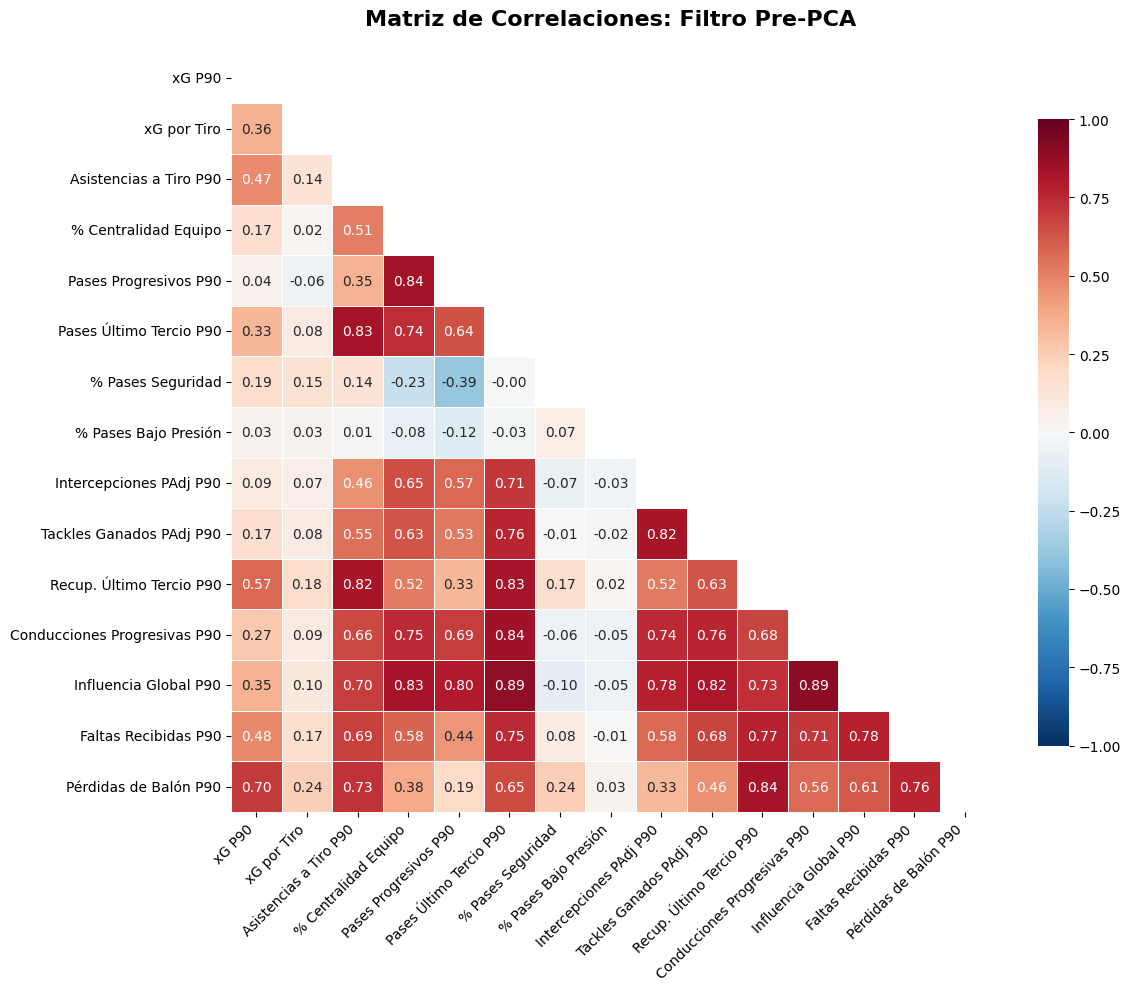

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# ==============================================================================
# 1. CARGA DE BASE DE DATOS
# ==============================================================================
ruta_archivo = '/content/drive/MyDrive/dataset_perfiles_jugadores_1516.csv'
df = pd.read_csv(ruta_archivo)

# Verificamos que la base esté lista y tenga las nuevas columnas
print("="*60)
print(f"✅ Base cargada: {df.shape[0]} jugadores y {df.shape[1]} columnas.")
print("="*60)
display(df[['player', 'team', 'competition_name', 'position_group']].head())

# ==============================================================================
# 2. DEFINICIÓN DE MÉTRICAS TÁCTICAS
# ==============================================================================
columnas_modelo = [
    'xG P90', 'xG por Tiro', 'Asistencias a Tiro P90',
    '% Centralidad Equipo', 'Pases Progresivos P90', 'Pases Último Tercio P90',
    '% Pases Seguridad', '% Pases Bajo Presión',
    'Intercepciones PAdj P90', 'Tackles Ganados PAdj P90',
    'Recup. Último Tercio P90',
    'Conducciones Progresivas P90', 'Influencia Global P90',
    'Faltas Recibidas P90', 'Pérdidas de Balón P90'
]

# ==============================================================================
# 3. DETECCIÓN AUTOMÁTICA DE MULTICOLINEALIDAD
# ==============================================================================
print("\n" + "="*80)
print(" 🔍 DETECCIÓN AUTOMÁTICA DE MULTICOLINEALIDAD (PRE-PCA)")
print("="*80)

# Definimos el umbral de peligro
UMBRAL_CORRELACION = 0.85

# Calculamos la matriz de correlación de Pearson usando 'df'
matriz_corr = df[columnas_modelo].corr()

# Detección Matemática de Pares Redundantes
pares_altos = []
for i in range(len(matriz_corr.columns)):
    for j in range(i+1, len(matriz_corr.columns)):
        valor_corr = matriz_corr.iloc[i, j]
        if abs(valor_corr) >= UMBRAL_CORRELACION:
            pares_altos.append((matriz_corr.columns[i], matriz_corr.columns[j], valor_corr))

print(f"⚠️ Pares de variables con correlación superior a {UMBRAL_CORRELACION}:\n")
if not pares_altos:
    print("✅ Excelente: No hay variables altamente redundantes. Vía libre para usar todas.")
else:
    for var1, var2, corr in pares_altos:
        print(f"   🔴 {var1} <---> {var2} (Correlación: {corr:.3f})")

print("\n" + "="*80)

# Visualización Táctica (Heatmap)
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Correlaciones: Filtro Pre-PCA', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Preprocesamiento Avanzado: Yeo-Johnson y Z-Score

Como comprobamos en el Análisis Exploratorio (EDA), nuestro dataset presentaba dos grandes desafíos matemáticos que podrían arruinar el Análisis de Componentes Principales (PCA) y el futuro Mapa Autoorganizado (SOM):

1.  **Diferencia de Escalas:** Métricas de volumen puro manejan rangos amplios (ej. Pases), mientras que otras de alta eficiencia fluctúan en fracciones decimales (ej. xG).
2.  **Asimetría Extrema (Skewness):** Una altísima concentración de ceros y colas largas estiradas por "extraterrestres" estadísticos (superestrellas).

Si aplicáramos un Z-Score tradicional sobre estos datos crudos, el PCA se vería "secuestrado" por los valores atípicos. El modelo aislaría a la élite en los extremos del mapa, pero amontonaría al 95% de los jugadores (la "clase media") en una nube densa e indiferenciable. Esto arruinaría nuestro objetivo principal: **crear un perfilamiento táctico detallado que nos permita detectar "talentos ocultos" (scouting estilo *Moneyball*)** con el mismo ADN táctico que las estrellas.

### 🛠️ La Solución: Enfoque Híbrido
Para forzar un ecosistema geométrico equitativo, aplicamos la transformación de **Yeo-Johnson**, un algoritmo adaptativo que calcula un exponente específico ($\lambda$) para cada métrica, comprimiendo las colas largas y acercando la distribución a una curva normal (campana de Gauss).

Posteriormente, el mismo pipeline aplica una estandarización **Z-Score** ($Z = \frac{x - \mu}{\sigma}$) para garantizar que todas las variables transformadas tengan media 0 y varianza 1.

### 📊 Resultados de la Transformación
La tabla de control de asimetría (*Skewness*) confirma el éxito rotundo del método:
*   Métricas con sesgos brutales como el `% Pases Bajo Presión` (9.799) cayeron a un estado casi perfectamente simétrico (0.160).
*   Las métricas de finalización (`xG`, `Asistencias a Tiro`), históricamente difíciles de estabilizar, fueron domadas y llevadas a un rango funcional para algoritmos de distancia.

Con esta matriz matemática pulida (`df_scaled`), garantizamos que el PCA agrupe a los jugadores estrictamente por sus **patrones de comportamiento táctico**, en igualdad de condiciones de escala y sin distorsiones extremas.

In [4]:
import pandas as pd
from sklearn.preprocessing import PowerTransformer
from IPython.display import display

print("="*80)
print(" ⚙️ PREPROCESAMIENTO AVANZADO: YEO-JOHNSON + Z-SCORE AUTOMÁTICO")
print("="*80)

# 1. Separar la información cualitativa
columnas_info = ['player', 'team', 'competition_name', 'position_group', 'position_detail', 'minutos_jugados']
variables_excluidas = ['Influencia Global P90', 'Duelos Aéreos Ganados P90']

# Extraemos estrictamente las 14 métricas tácticas restantes
columnas_metricas = [col for col in df.columns if col not in columnas_info and col not in variables_excluidas]

# Matriz de características originales
X_original = df[columnas_metricas]

# 2. Aplicar Yeo-Johnson (Incluye Estandarización Z-Score por defecto)
# standardize=True asegura que el resultado final tenga media 0 y desviación 1
pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_transformed = pt.fit_transform(X_original)

# Convertimos a DataFrame para el PCA
df_scaled = pd.DataFrame(X_transformed, columns=columnas_metricas)

# 3. Evaluación del Impacto de la Transformación
asimetria_antes = X_original.skew()
asimetria_despues = pd.DataFrame(X_transformed, columns=columnas_metricas).skew()

df_asimetria_comparativa = pd.DataFrame({
    'Asimetría Original': asimetria_antes,
    'Asimetría Yeo-Johnson': asimetria_despues
}).sort_values(by='Asimetría Original', ascending=False)

print("\n📊 TABLA COMPARATIVA DE ASIMETRÍA (YEO-JOHNSON)")
print("-" * 80)
display(df_asimetria_comparativa.round(3))

print("\n" + "="*80)
print(f"✅ Datos transformados óptimamente y estandarizados (Z-Score).")
print(f"✅ Matriz 'df_scaled' lista para el PCA ({df_scaled.shape[0]} filas x {df_scaled.shape[1]} columnas).")
print("="*80)

 ⚙️ PREPROCESAMIENTO AVANZADO: YEO-JOHNSON + Z-SCORE AUTOMÁTICO

📊 TABLA COMPARATIVA DE ASIMETRÍA (YEO-JOHNSON)
--------------------------------------------------------------------------------


,Asimetría Original,Asimetría Yeo-Johnson
% Pases Bajo Presión,9.799,0.160
xG P90,6.822,1.012
xG por Tiro,3.969,0.413
Asistencias a Tiro P90,3.826,0.623
Pérdidas de Balón P90,2.795,0.462
Tackles Ganados PAdj P90,2.517,0.611
Intercepciones PAdj P90,2.412,0.728
Conducciones Progresivas P90,2.372,0.354
Faltas Recibidas P90,2.357,0.469
Pases Último Tercio P90,2.335,0.216



✅ Datos transformados óptimamente y estandarizados (Z-Score).
✅ Matriz 'df_scaled' lista para el PCA (1699 filas x 14 columnas).


## 3. Análisis de Componentes Principales (PCA)

El PCA es una técnica de reducción de dimensionalidad que transforma nuestras 16 variables correlacionadas en un nuevo conjunto de variables incorrelacionadas (ortogonales) llamadas Componentes Principales.

Extraeremos dos piezas fundamentales de información matemática:
1.  **Varianza Explicada (Valores Propios / Eigenvalues):** Nos indica el porcentaje de información original que logra retener cada nuevo componente.
2.  **Cargas Factoriales (Loadings):** Es la correlación de Pearson entre las variables originales y los nuevos componentes. Multiplicaremos los vectores propios por la raíz cuadrada de los valores propios para obtener estas correlaciones reales y entender qué representa cada eje (ej. ¿El Componente 1 representa capacidad ofensiva o defensiva?).

In [5]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Ajustar el PCA con todas las componentes posibles para evaluar la varianza
pca = PCA()
pca.fit(df_scaled)

# 2. Cálculo de la Varianza Explicada y Acumulada
varianza_explicada = pca.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza_explicada)

df_varianza = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(varianza_explicada))],
    'Varianza Explicada (%)': varianza_explicada,
    'Varianza Acumulada (%)': varianza_acumulada
})

# 3. Cálculo de las Cargas Factoriales (Loadings)
# Fórmula: Eigenvectors * sqrt(Eigenvalues)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

df_loadings = pd.DataFrame(
    loadings,
    columns=[f'PC{i+1}' for i in range(len(columnas_metricas))],
    index=columnas_metricas
)

print("✅ Modelo PCA ajustado y matrices matemáticas extraídas.")

✅ Modelo PCA ajustado y matrices matemáticas extraídas.


In [6]:
print("="*70)
print(" 📊 1. RESUMEN DE VARIANZA EXPLICADA (Top 6 Componentes)")
print("="*70)
display(df_varianza.head(6).round(2))

print("\n" + "="*80)
print(" 📉 2. MATRIZ DE CARGAS FACTORIALES (Loadings)")
print(" (Rojo oscuro = Correlación Positiva Fuerte | Azul oscuro = Correlación Negativa Fuerte)")
print("="*80)

# 1. Seleccionamos las primeras 3 componentes y ordenamos por la influencia en PC1
tabla_cargas = df_loadings[['PC1', 'PC2', 'PC3','PC4', 'PC5', 'PC6']].sort_values(by='PC1', ascending=False)

# 2. Aplicamos el mapa de calor directamente sobre el DataFrame de Pandas
cargas_estilizadas = tabla_cargas.style.background_gradient(
    cmap='PiYG',   # RdBu_r: Red (Rojo) para positivos, Blue (Azul) para negativos
    vmin=-1,         # Límite inferior de la correlación
    vmax=1           # Límite superior de la correlación
).format(precision=3) # Mostramos 3 decimales para mantener la tabla limpia

# 3. Desplegamos la tabla coloreada
display(cargas_estilizadas)

 📊 1. RESUMEN DE VARIANZA EXPLICADA (Top 6 Componentes)


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC1,61.07,61.07
1,PC2,13.83,74.89
2,PC3,6.61,81.51
3,PC4,5.80,87.30
4,PC5,3.78,91.08
5,PC6,2.70,93.78



 📉 2. MATRIZ DE CARGAS FACTORIALES (Loadings)
 (Rojo oscuro = Correlación Positiva Fuerte | Azul oscuro = Correlación Negativa Fuerte)


,PC1,PC2,PC3,PC4,PC5,PC6
Pases Último Tercio P90,0.943,-0.178,0.030,-0.012,-0.194,0.079
Faltas Recibidas P90,0.918,-0.021,-0.030,-0.057,-0.046,-0.021
Conducciones Progresivas P90,0.913,-0.257,-0.012,0.004,-0.119,0.124
Recup. Último Tercio P90,0.881,0.237,-0.025,-0.151,-0.074,-0.205
Pérdidas de Balón P90,0.875,0.303,-0.041,-0.146,-0.099,-0.161
% Centralidad Equipo,0.868,-0.383,0.047,0.094,-0.094,0.201
Tackles Ganados PAdj P90,0.863,-0.090,0.065,-0.142,0.382,-0.084
Asistencias a Tiro P90,0.862,0.147,-0.036,-0.156,-0.212,-0.203
Pases Progresivos P90,0.817,-0.508,0.057,0.104,-0.052,0.190
Intercepciones PAdj P90,0.810,-0.196,0.079,-0.128,0.480,-0.019


## 4. Retención de Componentes y Exportación del Modelo

Basado en el análisis de la Varianza Explicada Acumulada, hemos decidido retener los **5 primeros Componentes Principales (PC1 a PC5)**, los cuales logran capturar el **91.08%** de toda la información táctica original del ecosistema.

Procedemos a unir estas 4 nuevas dimensiones geométricas con la información identificativa de los jugadores (Nombre, Equipo, Posición, etc.) y exportar la base de datos resultante. Asimismo, guardamos los objetos matemáticos (`PowerTransformer` y `PCA`) para garantizar la reproducibilidad del pipeline en futuros proyectos de scouting con nuevas bases de datos.

In [10]:
from sklearn.decomposition import PCA
import joblib
import pandas as pd

print("="*80)
print(" 💾 ENTRENAMIENTO FINAL Y EXPORTACIÓN PARA EL SOM")
print("="*80)

# 1. Aplicar el PCA definitivo sobre nuestros datos transformados (Yeo-Johnson)
pca = PCA()
X_pca = pca.fit_transform(df_scaled)

# 2. Seleccionar los componentes a retener (5 componentes)
n_componentes = 5

# Extraemos solo las primeras 5 columnas del resultado
df_pca_final = pd.DataFrame(X_pca[:, :n_componentes], columns=[f'PC{i+1}' for i in range(n_componentes)])

# 3. Unir los Componentes Principales con la información cualitativa original
# Usamos reset_index para evitar desalineaciones al concatenar
df_info = df[columnas_info].reset_index(drop=True)
df_som_input = pd.concat([df_info, df_scaled, df_pca_final], axis=1)

# 4. Definir las rutas de guardado en Google Drive
ruta_base = '/content/drive/MyDrive/'
ruta_csv_salida = ruta_base + 'dataset_pca_som_1516.csv'
ruta_modelo_pt = ruta_base + 'modelo_yeo_johnson.pkl'
ruta_modelo_pca = ruta_base + 'modelo_pca.pkl'

# 5. Guardar los archivos
df_som_input.to_csv(ruta_csv_salida, index=False)
joblib.dump(pt, ruta_modelo_pt) # 'pt' es el PowerTransformer de Yeo-Johnson que creamos antes
joblib.dump(pca, ruta_modelo_pca)

print(f"✅ Base de datos lista para el SOM exportada a: {ruta_csv_salida}")
print(f"   - Filas: {df_som_input.shape[0]} | Columnas: {df_som_input.shape[1]}")
print(f"   - Columnas incluidas: {list(df_som_input.columns)}")
print(f"✅ Transformador Yeo-Johnson guardado en: {ruta_modelo_pt}")
print(f"✅ Modelo PCA guardado en: {ruta_modelo_pca}")
print("\n🎉 SCRIPT 3 COMPLETADO EXITOSAMENTE. LISTOS PARA EL SCRIPT 4.")
print("="*80)

 💾 ENTRENAMIENTO FINAL Y EXPORTACIÓN PARA EL SOM
✅ Base de datos lista para el SOM exportada a: /content/drive/MyDrive/dataset_pca_som_1516.csv
   - Filas: 1699 | Columnas: 25
   - Columnas incluidas: ['player', 'team', 'competition_name', 'position_group', 'position_detail', 'minutos_jugados', 'xG P90', 'xG por Tiro', 'Asistencias a Tiro P90', '% Centralidad Equipo', 'Pases Progresivos P90', 'Pases Último Tercio P90', '% Pases Seguridad', '% Pases Bajo Presión', 'Intercepciones PAdj P90', 'Tackles Ganados PAdj P90', 'Recup. Último Tercio P90', 'Conducciones Progresivas P90', 'Faltas Recibidas P90', 'Pérdidas de Balón P90', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5']
✅ Transformador Yeo-Johnson guardado en: /content/drive/MyDrive/modelo_yeo_johnson.pkl
✅ Modelo PCA guardado en: /content/drive/MyDrive/modelo_pca.pkl

🎉 SCRIPT 3 COMPLETADO EXITOSAMENTE. LISTOS PARA EL SCRIPT 4.
